In [1]:
import numpy as np
import pandas as pd

import json

with open(r"C:\Users\USER\Desktop\資訊所實習\計畫\simulation_data_for_Biological_functions_of_the_DGPs\pathway_db.json", "r") as f:
    pathway_db = json.load(f)

In [2]:
pathway_db

{'Virus_Core': ['Gene1',
  'Gene2',
  'Gene3',
  'Gene4',
  'Gene5',
  'Gene6',
  'Gene7',
  'Gene8',
  'Gene9',
  'Gene10',
  'Gene11',
  'Gene12',
  'Gene13',
  'Gene14',
  'Gene15',
  'Gene16',
  'Gene17',
  'Gene18',
  'Gene19',
  'Gene20'],
 'GramPos_Core': ['Gene21',
  'Gene22',
  'Gene23',
  'Gene24',
  'Gene25',
  'Gene26',
  'Gene27',
  'Gene28',
  'Gene29',
  'Gene30',
  'Gene31',
  'Gene32',
  'Gene33',
  'Gene34',
  'Gene35',
  'Gene36',
  'Gene37',
  'Gene38',
  'Gene39',
  'Gene40'],
 'GramNeg_Core': ['Gene41',
  'Gene42',
  'Gene43',
  'Gene44',
  'Gene45',
  'Gene46',
  'Gene47',
  'Gene48',
  'Gene49',
  'Gene50',
  'Gene51',
  'Gene52',
  'Gene53',
  'Gene54',
  'Gene55',
  'Gene56',
  'Gene57',
  'Gene58',
  'Gene59',
  'Gene60'],
 'Non_Core': ['Gene61',
  'Gene62',
  'Gene63',
  'Gene64',
  'Gene65',
  'Gene66',
  'Gene67',
  'Gene68',
  'Gene69',
  'Gene70',
  'Gene71',
  'Gene72',
  'Gene73',
  'Gene74',
  'Gene75',
  'Gene76',
  'Gene77',
  'Gene78',
  'Gene79',


In [3]:
expression_df = pd.read_csv(r"C:\Users\USER\Desktop\資訊所實習\計畫\simulation_data_for_Biological_functions_of_the_DGPs\expression_df.csv")

In [4]:
print(expression_df.head())

  Unnamed: 0      Gene1     Gene2     Gene3     Gene4     Gene5     Gene6  \
0         P1   9.658187  7.861736  8.966346  6.523030  6.234294  4.765863   
1         P2   9.487705  7.579355  6.271372  4.197723  7.595112  5.404051   
2         P3  10.381570  8.560785  7.977246  6.053802  5.860871  4.062175   
3         P4   9.472944  7.439819  7.098984  5.610370  6.788576  5.117327   
4         P5   9.759779  7.400625  7.022041  5.046981  7.291514  5.622850   

      Gene7     Gene8      Gene9  ...    Gene92    Gene93    Gene94    Gene95  \
0  7.674316  5.767435   7.964254  ...  5.968645  4.297947  4.672338  4.607892   
1  6.977527  5.174578   6.985776  ...  5.856399  5.214094  3.754261  5.173181   
2  7.190291  5.513786  10.221951  ...  4.506999  4.410635  5.849602  5.357015   
3  6.516104  4.408429   6.595745  ...  5.491919  3.679767  6.831459  6.179440   
4  6.545683  4.857621   7.256974  ...  6.479944  5.077368  4.138716  6.523124   

     Gene96    Gene97    Gene98    Gene99   Gene10

In [5]:
with open(r"C:\Users\USER\Desktop\資訊所實習\計畫\simulation_data_for_Biological_functions_of_the_DGPs\gene_to_pathway.json", "r") as f:
    gene_to_pathway = json.load(f)

In [6]:
gene_to_pathway

{'Gene1': ['Virus_Core', 'Random_Pathway2'],
 'Gene2': ['Virus_Core', 'Random_Pathway3', 'Random_Pathway4'],
 'Gene3': ['Virus_Core',
  'Random_Pathway2',
  'Random_Pathway3',
  'Random_Pathway6'],
 'Gene4': ['Virus_Core',
  'Random_Pathway3',
  'Random_Pathway4',
  'Random_Pathway5'],
 'Gene5': ['Virus_Core',
  'Random_Pathway2',
  'Random_Pathway3',
  'Random_Pathway5'],
 'Gene6': ['Virus_Core',
  'Random_Pathway2',
  'Random_Pathway4',
  'Random_Pathway6'],
 'Gene7': ['Virus_Core', 'Random_Pathway1', 'Random_Pathway2'],
 'Gene8': ['Virus_Core', 'Random_Pathway6'],
 'Gene9': ['Virus_Core', 'Random_Pathway2'],
 'Gene10': ['Virus_Core', 'Random_Pathway3', 'Random_Pathway5'],
 'Gene11': ['Virus_Core',
  'Random_Pathway2',
  'Random_Pathway5',
  'Random_Pathway6'],
 'Gene12': ['Virus_Core',
  'Random_Pathway3',
  'Random_Pathway4',
  'Random_Pathway5',
  'Random_Pathway6'],
 'Gene13': ['Virus_Core', 'Random_Pathway2', 'Random_Pathway5'],
 'Gene14': ['Virus_Core', 'Random_Pathway1', 'Rand

In [7]:
from itertools import combinations

def build_within_pathway_gene_pairs(expr_df, pathway_dict,
                                    sample_col="Unnamed: 0",
                                    label_col="Label"):
    """
    expr_df : gene expression dataframe
    pathway_dict : pathway -> list of genes

    return:
        pair_df : 每個 sample 的 gene pair binary feature
        pair_info : 每個 pair 屬於哪個 pathway
    """

    # 保留 sample id
    pair_df = pd.DataFrame()
    pair_df[sample_col] = expr_df[sample_col]

    pair_info = {}

    for pathway, genes in pathway_dict.items():

        # 只保留資料中存在的 gene
        genes = [g for g in genes if g in expr_df.columns]

        for g1, g2 in combinations(genes, 2):

            col_name = f"{pathway}|{g1}>{g2}"

            pair_df[col_name] = (
                expr_df[g1] > expr_df[g2]
            ).astype(int)

            pair_info[col_name] = {
                "pathway": pathway,
                "gene1": g1,
                "gene2": g2
            }

    if label_col in expr_df.columns:
        pair_df[label_col] = expr_df[label_col]

    return pair_df, pair_info

In [8]:
pair_df, pair_info = build_within_pathway_gene_pairs(
    expr_df=expression_df,
    pathway_dict=pathway_db
)

C:\Users\USER\AppData\Local\Temp\ipykernel_26508\106911897.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pair_df[col_name] = (
C:\Users\USER\AppData\Local\Temp\ipykernel_26508\106911897.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pair_df[col_name] = (
C:\Users\USER\AppData\Local\Temp\ipykernel_26508\106911897.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(

In [9]:
print(pair_df.head())

  Unnamed: 0  Virus_Core|Gene1>Gene2  Virus_Core|Gene1>Gene3  \
0         P1                       1                       1   
1         P2                       1                       1   
2         P3                       1                       1   
3         P4                       1                       1   
4         P5                       1                       1   

   Virus_Core|Gene1>Gene4  Virus_Core|Gene1>Gene5  Virus_Core|Gene1>Gene6  \
0                       1                       1                       1   
1                       1                       1                       1   
2                       1                       1                       1   
3                       1                       1                       1   
4                       1                       1                       1   

   Virus_Core|Gene1>Gene7  Virus_Core|Gene1>Gene8  Virus_Core|Gene1>Gene9  \
0                       1                       1                       1  

In [10]:
df = pair_df.copy()

df["Target"] = (df["Label"] == "Virus").astype(int)

In [11]:
print(df["Target"].value_counts())

Target
0    75
1    25
Name: count, dtype: int64


In [12]:
df

,Unnamed: 0,Virus_Core|Gene1>Gene2,Virus_Core|Gene1>Gene3,Virus_Core|Gene1>Gene4,Virus_Core|Gene1>Gene5,Virus_Core|Gene1>Gene6,Virus_Core|Gene1>Gene7,Virus_Core|Gene1>Gene8,Virus_Core|Gene1>Gene9,Virus_Core|Gene1>Gene10,...,Random_Pathway6|Gene32>Gene70,Random_Pathway6|Gene32>Gene73,Random_Pathway6|Gene42>Gene51,Random_Pathway6|Gene42>Gene70,Random_Pathway6|Gene42>Gene73,Random_Pathway6|Gene51>Gene70,Random_Pathway6|Gene51>Gene73,Random_Pathway6|Gene70>Gene73,Label,Target
0,P1,1,1,1,1,1,1,1,1,1,...,1,1,0,1,1,1,1,0,Virus,1
1,P2,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,Virus,1
2,P3,1,1,1,1,1,1,1,1,1,...,1,0,1,0,0,0,0,0,Virus,1
3,P4,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,1,0,0,Virus,1
4,P5,1,1,1,1,1,1,1,1,1,...,0,0,1,1,1,1,1,1,Virus,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,P96,0,0,1,0,0,0,0,1,0,...,1,1,0,0,0,1,1,0,Non,0
96,P97,0,0,0,0,0,1,0,0,0,...,0,0,0,1,1,1,1,1,Non,0
97,P98,0,0,0,0,1,0,0,1,1,...,1,0,0,1,0,1,0,0,Non,0
98,P99,1,0,1,1,1,1,0,1,1,...,0,0,1,1,0,0,0,0,Non,0


In [13]:
def contingency_table(feature, target):

    a = ((feature == 1) & (target == 1)).sum()
    b = ((feature == 1) & (target == 0)).sum()
    c = ((feature == 0) & (target == 1)).sum()
    d = ((feature == 0) & (target == 0)).sum()

    return a,b,c,d

In [14]:
feature = df["Virus_Core|Gene1>Gene2"]

a,b,c,d = contingency_table(feature, df["Target"])

print(a,b,c,d)

25 39 0 36


In [15]:
from math import comb

def fisher_probability(a,b,c,d):

    n = a+b+c+d

    row1 = a+b
    row2 = c+d

    col1 = a+c

    p = comb(row1,a)*comb(row2,c)/comb(n,col1)

    return p

In [16]:
p = fisher_probability(a,b,c,d)

print(p)

1.6536358913414443e-06


In [17]:
from math import comb

def fisher_exact(a,b,c,d):

    row1 = a+b
    row2 = c+d

    col1 = a+c
    col2 = b+d

    n = row1+row2

    observed = comb(row1,a)*comb(row2,c)/comb(n,col1)

    lower = max(0,col1-row2)
    upper = min(col1,row1)

    pvalue = 0

    for aa in range(lower,upper+1):

        cc = col1-aa
        bb = row1-aa
        dd = row2-cc

        p = comb(row1,aa)*comb(row2,cc)/comb(n,col1)

        if p <= observed + 1e-12:
            pvalue += p

    return pvalue

In [18]:
results = []

feature_cols = [
    c for c in df.columns
    if c not in ["Unnamed: 0","Label","Target"]
]

for feature in feature_cols:

    a,b,c,d = contingency_table(
        df[feature],
        df["Target"]
    )

    p = fisher_exact(a,b,c,d)

    results.append([
        feature,
        a,b,c,d,
        p
    ])

In [19]:
result_df = pd.DataFrame(
    results,
    columns=[
        "GenePair",
        "a","b","c","d",
        "Pvalue"
    ]
)

result_df = result_df.sort_values(
    "Pvalue"
)

result_df

,GenePair,a,b,c,d,Pvalue
1183,Random_Pathway2|Gene9>Gene21,24,13,1,62,9.330719e-13
1360,Random_Pathway2|Gene1>Gene21,25,17,0,58,1.050069e-12
2139,Random_Pathway3|Gene61>Gene2,0,57,25,18,2.508498e-12
3292,Random_Pathway5|Gene5>Gene69,25,18,0,57,2.508498e-12
2484,Random_Pathway4|Gene61>Gene2,0,57,25,18,2.508498e-12
...,...,...,...,...,...,...
3083,Random_Pathway5|Gene72>Gene89,13,38,12,37,1.000000e+00
3738,Random_Pathway6|Gene8>Gene84,14,43,11,32,1.000000e+00
3066,Random_Pathway5|Gene44>Gene46,13,38,12,37,1.000000e+00
3715,Random_Pathway6|Gene38>Gene58,10,32,15,43,1.000000e+00


In [20]:
def benjamini_hochberg(pvalues):

    m = len(pvalues)

    ranked = sorted(
        enumerate(pvalues),
        key=lambda x:x[1]
    )

    q = [0]*m

    prev = 1

    for rank in range(m-1,-1,-1):

        idx,p = ranked[rank]

        value = p*m/(rank+1)

        value = min(value,prev)

        q[idx]=value

        prev=value

    return q

In [21]:
result_df["FDR"] = benjamini_hochberg(
    result_df["Pvalue"].tolist()
)

In [22]:
result_df.sort_values("FDR")

,GenePair,a,b,c,d,Pvalue,FDR
1183,Random_Pathway2|Gene9>Gene21,24,13,1,62,9.330719e-13,1.956127e-09
1360,Random_Pathway2|Gene1>Gene21,25,17,0,58,1.050069e-12,1.956127e-09
2139,Random_Pathway3|Gene61>Gene2,0,57,25,18,2.508498e-12,1.956127e-09
3292,Random_Pathway5|Gene5>Gene69,25,18,0,57,2.508498e-12,1.956127e-09
2484,Random_Pathway4|Gene61>Gene2,0,57,25,18,2.508498e-12,1.956127e-09
...,...,...,...,...,...,...,...
3083,Random_Pathway5|Gene72>Gene89,13,38,12,37,1.000000e+00,1.000000e+00
3738,Random_Pathway6|Gene8>Gene84,14,43,11,32,1.000000e+00,1.000000e+00
3066,Random_Pathway5|Gene44>Gene46,13,38,12,37,1.000000e+00,1.000000e+00
3715,Random_Pathway6|Gene38>Gene58,10,32,15,43,1.000000e+00,1.000000e+00


In [23]:
print(result_df.head())

                          GenePair   a   b   c   d        Pvalue           FDR
1183  Random_Pathway2|Gene9>Gene21  24  13   1  62  9.330719e-13  1.956127e-09
1360  Random_Pathway2|Gene1>Gene21  25  17   0  58  1.050069e-12  1.956127e-09
2139  Random_Pathway3|Gene61>Gene2   0  57  25  18  2.508498e-12  1.956127e-09
3292  Random_Pathway5|Gene5>Gene69  25  18   0  57  2.508498e-12  1.956127e-09
2484  Random_Pathway4|Gene61>Gene2   0  57  25  18  2.508498e-12  1.956127e-09


In [24]:
result_df["Pathway"] = result_df["GenePair"].str.split("|").str[0]

In [25]:
sig = result_df[result_df["FDR"] < 0.05]

print(sig["Pathway"].value_counts())

Pathway
Random_Pathway2    214
Random_Pathway3    157
Random_Pathway5    108
Virus_Core         108
Random_Pathway4     78
Random_Pathway6     66
Random_Pathway1     65
GramNeg_Core        17
GramPos_Core        11
Non_Core            11
Name: count, dtype: int64


In [26]:
gene_count = {}

for pathway, genes in pathway_db.items():
    gene_count[pathway] = len(genes)

In [27]:
pair_count = {}

for pathway, genes in pathway_db.items():

    n = len(genes)

    pair_count[pathway] = n * (n - 1) // 2

In [28]:
sig_df = result_df[result_df["FDR"] < 0.05].copy()

In [29]:
sig_df["Pathway"] = sig_df["GenePair"].str.split("|").str[0]

In [30]:
sig_count = sig_df["Pathway"].value_counts().to_dict()

In [31]:
summary = []

for pathway in pathway_db.keys():

    genes = gene_count[pathway]

    total_pairs = pair_count[pathway]

    significant_pairs = sig_count.get(pathway, 0)

    ratio = significant_pairs / total_pairs

    summary.append([
        pathway,
        genes,
        total_pairs,
        significant_pairs,
        ratio
    ])

In [32]:
summary_df = pd.DataFrame(
    summary,
    columns=[
        "Pathway",
        "GeneCount",
        "TotalPairs",
        "SignificantPairs",
        "Ratio"
    ]
)

In [33]:
summary_df = summary_df.sort_values(
    "Ratio",
    ascending=False
)

summary_df["BackgroundPairs"] = len(result_df)
summary_df["BackgroundSignificant"] = len(sig_df)

print(summary_df)

           Pathway  GeneCount  TotalPairs  SignificantPairs     Ratio  \
0       Virus_Core         20         190               108  0.568421   
5  Random_Pathway2         35         595               214  0.359664   
6  Random_Pathway3         38         703               157  0.223329   
9  Random_Pathway6         26         325                66  0.203077   
7  Random_Pathway4         30         435                78  0.179310   
4  Random_Pathway1         28         378                65  0.171958   
8  Random_Pathway5         38         703               108  0.153627   
2     GramNeg_Core         20         190                17  0.089474   
1     GramPos_Core         20         190                11  0.057895   
3         Non_Core         20         190                11  0.057895   

   BackgroundPairs  BackgroundSignificant  
0             3899                    835  
5             3899                    835  
6             3899                    835  
9             3899  

In [34]:
from math import comb

def hyper_probability(N, M, K, x):
    """
    P(X = x)

    N : total pairs
    M : significant pairs
    K : pathway pairs
    x : significant pairs inside pathway
    """

    if x < 0 or x > K:
        return 0

    if x > M:
        return 0

    if K - x > N - M:
        return 0

    return (
        comb(M, x) *
        comb(N - M, K - x)
        /
        comb(N, K)
    )

In [35]:
def hyper_pvalue(N, M, K, x):
    """
    P(X >= x)
    """

    upper = min(K, M)

    p = 0

    for i in range(x, upper + 1):
        p += hyper_probability(N, M, K, i)

    return p

In [36]:
enrichment_results = []

N = summary_df["BackgroundPairs"].iloc[0]
M = summary_df["BackgroundSignificant"].iloc[0]

for _, row in summary_df.iterrows():

    pathway = row["Pathway"]

    K = row["TotalPairs"]

    x = row["SignificantPairs"]

    p = hyper_pvalue(
        N=N,
        M=M,
        K=K,
        x=x
    )

    enrichment_results.append(p)

In [37]:
summary_df["Enrichment_P"] = enrichment_results

In [38]:
summary_df["Enrichment_FDR"] = benjamini_hochberg(
    summary_df["Enrichment_P"].tolist()
)

In [39]:
summary_df = summary_df.sort_values(
    "Enrichment_P"
)

print(summary_df)

           Pathway  GeneCount  TotalPairs  SignificantPairs     Ratio  \
0       Virus_Core         20         190               108  0.568421   
5  Random_Pathway2         35         595               214  0.359664   
6  Random_Pathway3         38         703               157  0.223329   
9  Random_Pathway6         26         325                66  0.203077   
7  Random_Pathway4         30         435                78  0.179310   
4  Random_Pathway1         28         378                65  0.171958   
8  Random_Pathway5         38         703               108  0.153627   
2     GramNeg_Core         20         190                17  0.089474   
1     GramPos_Core         20         190                11  0.057895   
3         Non_Core         20         190                11  0.057895   

   BackgroundPairs  BackgroundSignificant  Enrichment_P  Enrichment_FDR  
0             3899                    835  6.698096e-28    6.698096e-27  
5             3899                    835  3.110

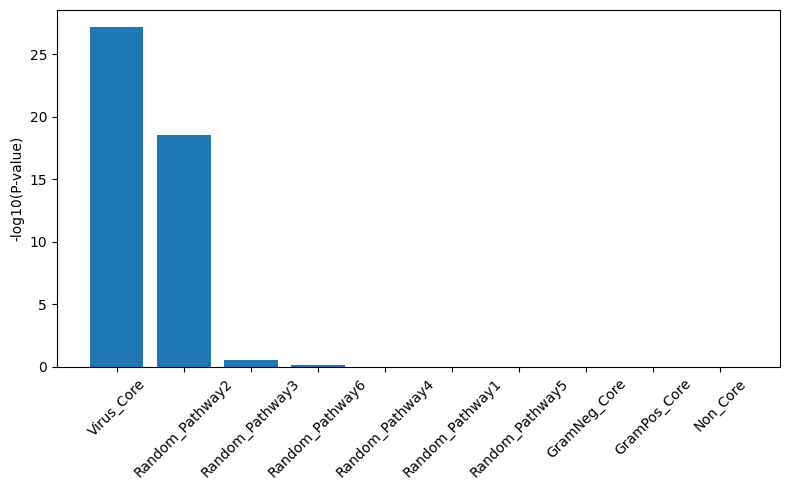

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    summary_df["Pathway"],
    -np.log10(summary_df["Enrichment_P"])
)

plt.xticks(rotation=45)

plt.ylabel("-log10(P-value)")

plt.tight_layout()

plt.show()

In [41]:
background_ratio = summary_df["BackgroundSignificant"].iloc[0] / summary_df["BackgroundPairs"].iloc[0]

summary_df["FoldEnrichment"] = summary_df["Ratio"] / background_ratio

In [42]:
virus_genes = set(pathway_db["Virus_Core"])

overlap_dict = {}

for pathway, genes in pathway_db.items():

    overlap_dict[pathway] = len(set(genes) & virus_genes)

In [43]:
summary_df["VirusOverlap"] = summary_df["Pathway"].map(overlap_dict)

In [44]:
summary_df = summary_df.sort_values(
    "FoldEnrichment",
    ascending=False
)

print(summary_df[["Pathway","VirusOverlap"]])

           Pathway  VirusOverlap
0       Virus_Core            20
5  Random_Pathway2            11
6  Random_Pathway3             7
9  Random_Pathway6             6
7  Random_Pathway4             6
4  Random_Pathway1             4
8  Random_Pathway5             9
2     GramNeg_Core             0
1     GramPos_Core             0
3         Non_Core             0


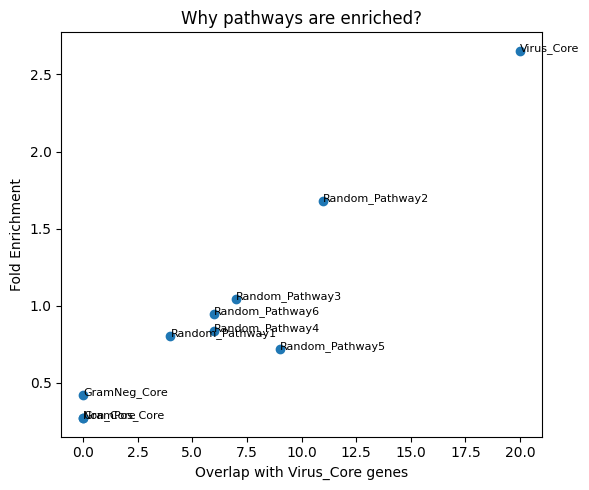

In [45]:
plt.figure(figsize=(6,5))

plt.scatter(
    summary_df["VirusOverlap"],
    summary_df["FoldEnrichment"]
)

for i, row in summary_df.iterrows():
    plt.text(
        row["VirusOverlap"],
        row["FoldEnrichment"],
        row["Pathway"],
        fontsize=8
    )

plt.xlabel("Overlap with Virus_Core genes")
plt.ylabel("Fold Enrichment")

plt.title("Why pathways are enriched?")

plt.tight_layout()

plt.show()

In [46]:
summary_df.to_csv("virus_enrichment.csv", index=False)